
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

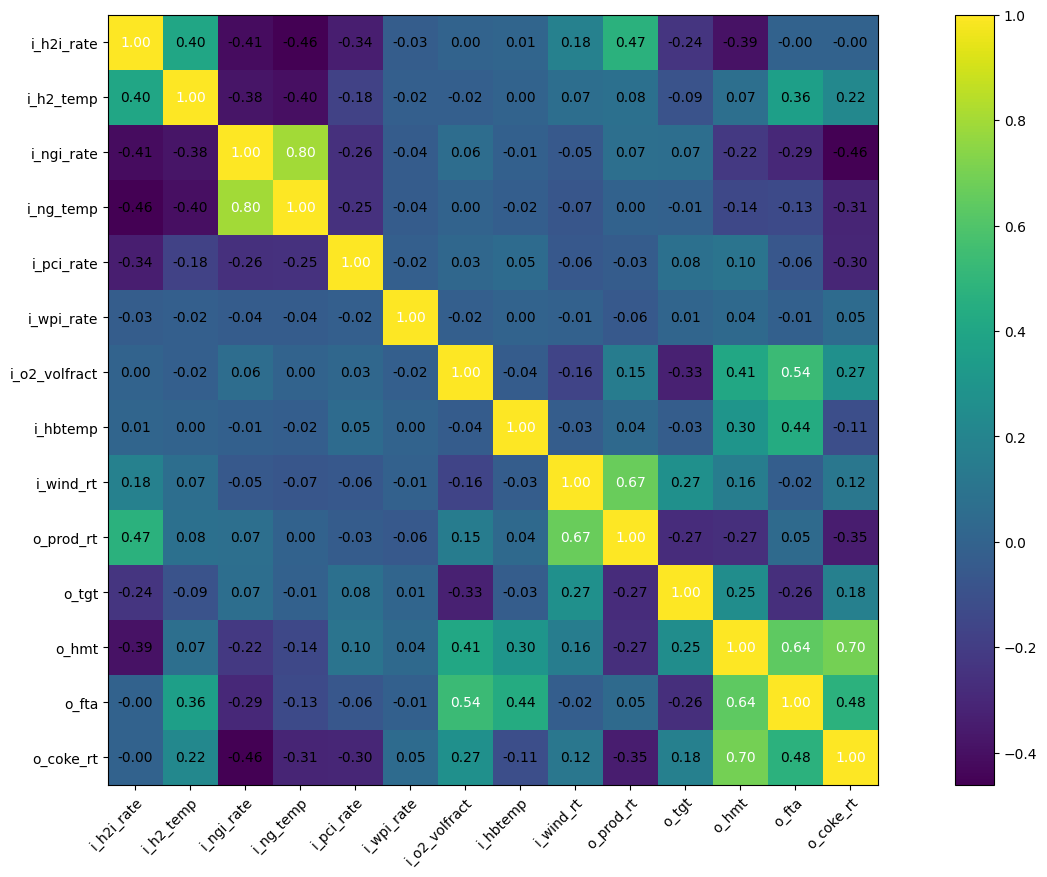

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.2898576855659485
100 ..... 0.48724365234375
200 ..... 0.26600635051727295
300 ..... 0.1541116088628769
400 ..... 0.2398703694343567
500 ..... 0.27153250575065613
600 ..... 0.21528802812099457
700 ..... 0.2333901971578598
800 ..... 0.4601089358329773
900 ..... 0.1849147230386734


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.4598, 1301.6656, 8436.7979, 2307.3210,  417.2255]])
y_deviations: tensor([[  50.9008,  526.9814, 1518.6256,  212.9777,   49.5814]])
x_means: tensor([[  12.4031,   18.8450,   41.5866,   25.6197,  414.7787, 1440.2800,
          198.5009]])
x_deviations: tensor([[ 15.2814,  45.1579,  46.5237,   3.3211, 271.5070, 157.2885,  26.6389]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  46.5590,  774.6843, 6918.1724, 2094.3433,  367.6441]])
tensor([[ 148.3606, 1828.6470, 9955.4238, 2520.2988,  466.8069]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.8783,  -26.3130,   -4.9371,   22.2985,  143.2717, 1282.9915,
          171.8620]])
tensor([[  27.6845,   64.0029,   88.1104,   28.9408,  686.2856, 1597.5686,
          225.1398]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])



get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [32]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [33]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [34]:

lambda_cost = 0.1        ## 0.01    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [35]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
   
    
    for j in range(2000):             ## 1000
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        loss_main  = torch.mean((current_y - target_y)**2)
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        loss       = loss_main + loss_cost + loss_z_reg
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 200 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "total loss", loss      )
            print( "loss_main",  loss_main )
            print( "loss_cost",  loss_cost )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')




iteration 0 cost: 534.5031127929688...H2, PCI, NGI: [[ 94.99527  108.26196   92.520134]]
real cost       : 120.0
total loss tensor([63.1316], grad_fn=<AddBackward0>)
loss_main tensor(9.6792, grad_fn=<MeanBackward0>)
loss_cost tensor([53.4503], grad_fn=<MulBackward0>)
iteration 200 cost: 158.635009765625...H2, PCI, NGI: [[27.951777 31.753632 30.148571]]
real cost       : 120.0
total loss tensor([16.2040], grad_fn=<AddBackward0>)
loss_main tensor(0.3175, grad_fn=<MeanBackward0>)
loss_cost tensor([15.8635], grad_fn=<MulBackward0>)
iteration 400 cost: 74.4390869140625...H2, PCI, NGI: [[13.015126 14.294307 16.168543]]
real cost       : 120.0
total loss tensor([7.7433], grad_fn=<AddBackward0>)
loss_main tensor(0.2536, grad_fn=<MeanBackward0>)
loss_cost tensor([7.4439], grad_fn=<MulBackward0>)
iteration 600 cost: 44.74912643432617...H2, PCI, NGI: [[ 7.7973275  8.277613  10.564405 ]]
real cost       : 120.0
total loss tensor([5.0405], grad_fn=<AddBackward0>)
loss_main tensor(0.5022, grad_fn=<M

iteration 1800 cost: 15.20461368560791...H2, PCI, NGI: [[2.5606623 2.1922941 5.5393414]]
real cost       : 75.0
total loss tensor([4.0153], grad_fn=<AddBackward0>)
loss_main tensor(2.3884, grad_fn=<MeanBackward0>)
loss_cost tensor([1.5205], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   2.2060661    1.8843883    4.9552593   21.487076   444.3656
  1488.5939     201.65765  ]]
real
[   0.    0.  150.   27.  300. 1600.  195.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[ 127.2780, 1706.7776, 6857.0068, 2368.3254,  468.3722]])
y real
tensor([[  84.2295, 1127.6937, 9396.9619, 2326.0005,  347.3909]])
3
********************************
iteration 0 cost: 540.8941040039062...H2, PCI, NGI: [[ 90.79921 107.40398 140.58655]]
real cost       : 60.0
total loss tensor([62.7653], grad_fn=<AddBackward0>)
loss_main tensor(8.6739, grad_fn=<MeanBackward0>)
loss_cost tensor([54.0894], grad_fn=<MulBac

iteration 1200 cost: 22.73560905456543...H2, PCI, NGI: [[3.8738055 3.2982085 7.884357 ]]
real cost       : 160.0
total loss tensor([4.8845], grad_fn=<AddBackward0>)
loss_main tensor(2.5262, grad_fn=<MeanBackward0>)
loss_cost tensor([2.2736], grad_fn=<MulBackward0>)
iteration 1400 cost: 18.740800857543945...H2, PCI, NGI: [[3.203294  2.6720154 6.5112176]]
real cost       : 160.0
total loss tensor([4.6718], grad_fn=<AddBackward0>)
loss_main tensor(2.7089, grad_fn=<MeanBackward0>)
loss_cost tensor([1.8741], grad_fn=<MulBackward0>)
iteration 1600 cost: 15.897603988647461...H2, PCI, NGI: [[2.7200727 2.23171   5.571206 ]]
real cost       : 160.0
total loss tensor([4.5427], grad_fn=<AddBackward0>)
loss_main tensor(2.8600, grad_fn=<MeanBackward0>)
loss_cost tensor([1.5898], grad_fn=<MulBackward0>)
iteration 1800 cost: 13.697879791259766...H2, PCI, NGI: [[2.3423185 1.8957317 4.8657484]]
real cost       : 160.0
total loss tensor([4.4531], grad_fn=<AddBackward0>)
loss_main tensor(2.9853, grad_fn=<

iteration 600 cost: 47.73147201538086...H2, PCI, NGI: [[ 7.2734623 12.123564  13.028116 ]]
real cost       : 30.0
total loss tensor([5.0182], grad_fn=<AddBackward0>)
loss_main tensor(0.2018, grad_fn=<MeanBackward0>)
loss_cost tensor([4.7731], grad_fn=<MulBackward0>)
iteration 800 cost: 31.65375518798828...H2, PCI, NGI: [[4.8253784 7.9607644 8.782956 ]]
real cost       : 30.0
total loss tensor([3.3342], grad_fn=<AddBackward0>)
loss_main tensor(0.1145, grad_fn=<MeanBackward0>)
loss_cost tensor([3.1654], grad_fn=<MulBackward0>)
iteration 1000 cost: 22.594650268554688...H2, PCI, NGI: [[3.4502356 5.6235356 6.3403416]]
real cost       : 30.0
total loss tensor([2.4203], grad_fn=<AddBackward0>)
loss_main tensor(0.0955, grad_fn=<MeanBackward0>)
loss_cost tensor([2.2595], grad_fn=<MulBackward0>)
iteration 1200 cost: 16.92488670349121...H2, PCI, NGI: [[2.5869627 4.1808133 4.7924476]]
real cost       : 30.0
total loss tensor([1.8574], grad_fn=<AddBackward0>)
loss_main tensor(0.0897, grad_fn=<MeanB

iteration 200 cost: 194.08473205566406...H2, PCI, NGI: [[32.296314 41.755787 46.28739 ]]
real cost       : 60.0
total loss tensor([20.9039], grad_fn=<AddBackward0>)
loss_main tensor(1.4744, grad_fn=<MeanBackward0>)
loss_cost tensor([19.4085], grad_fn=<MulBackward0>)
iteration 400 cost: 91.75582122802734...H2, PCI, NGI: [[15.053551 19.150791 24.781658]]
real cost       : 60.0
total loss tensor([9.9687], grad_fn=<AddBackward0>)
loss_main tensor(0.7549, grad_fn=<MeanBackward0>)
loss_cost tensor([9.1756], grad_fn=<MulBackward0>)
iteration 600 cost: 54.373538970947266...H2, PCI, NGI: [[ 8.806926 11.063502 16.164665]]
real cost       : 60.0
total loss tensor([6.2690], grad_fn=<AddBackward0>)
loss_main tensor(0.7818, grad_fn=<MeanBackward0>)
loss_cost tensor([5.4374], grad_fn=<MulBackward0>)
iteration 800 cost: 37.03285217285156...H2, PCI, NGI: [[ 5.931661   7.3553343 11.9017515]]
real cost       : 60.0
total loss tensor([4.6488], grad_fn=<AddBackward0>)
loss_main tensor(0.8853, grad_fn=<Mean

...

iteration 200 cost: 230.58065795898438...H2, PCI, NGI: [[44.88163 30.5641  40.98008]]
real cost       : 120.0
total loss tensor([23.9802], grad_fn=<AddBackward0>)
loss_main tensor(0.9022, grad_fn=<MeanBackward0>)
loss_cost tensor([23.0581], grad_fn=<MulBackward0>)
iteration 400 cost: 106.30360412597656...H2, PCI, NGI: [[20.221594 14.106111 22.62224 ]]
real cost       : 120.0
total loss tensor([10.8114], grad_fn=<AddBackward0>)
loss_main tensor(0.1419, grad_fn=<MeanBackward0>)
loss_cost tensor([10.6304], grad_fn=<MulBackward0>)
iteration 600 cost: 61.54027557373047...H2, PCI, NGI: [[11.493345  8.467983 14.197819]]
real cost       : 120.0
total loss tensor([6.3283], grad_fn=<AddBackward0>)
loss_main tensor(0.1219, grad_fn=<MeanBackward0>)
loss_cost tensor([6.1540], grad_fn=<MulBackward0>)
iteration 800 cost: 41.42694091796875...H2, PCI, NGI: [[7.6873484 5.6838565 9.987378 ]]
real cost       : 120.0
total loss tensor([4.5134], grad_fn=<AddBackward0>)
loss_main tensor(0.3068, grad_fn=<Mean

iteration 200 cost: 215.2459716796875...H2, PCI, NGI: [[37.831123 40.57138  46.700188]]
real cost       : 80.0
total loss tensor([22.3261], grad_fn=<AddBackward0>)
loss_main tensor(0.7876, grad_fn=<MeanBackward0>)
loss_cost tensor([21.5246], grad_fn=<MulBackward0>)
iteration 400 cost: 102.21524810791016...H2, PCI, NGI: [[17.66045  19.004238 25.138409]]
real cost       : 80.0
total loss tensor([10.3750], grad_fn=<AddBackward0>)
loss_main tensor(0.1283, grad_fn=<MeanBackward0>)
loss_cost tensor([10.2215], grad_fn=<MulBackward0>)
iteration 600 cost: 59.89269256591797...H2, PCI, NGI: [[10.231962 10.956832 16.01602 ]]
real cost       : 80.0
total loss tensor([6.1178], grad_fn=<AddBackward0>)
loss_main tensor(0.0920, grad_fn=<MeanBackward0>)
loss_cost tensor([5.9893], grad_fn=<MulBackward0>)
iteration 800 cost: 40.317386627197266...H2, PCI, NGI: [[ 6.871324  7.187607 11.28896 ]]
real cost       : 80.0
total loss tensor([4.3392], grad_fn=<AddBackward0>)
loss_main tensor(0.2612, grad_fn=<MeanB

iteration 200 cost: 196.05120849609375...H2, PCI, NGI: [[35.673542 31.75475  43.20459 ]]
real cost       : 90.0
total loss tensor([21.2043], grad_fn=<AddBackward0>)
loss_main tensor(1.5754, grad_fn=<MeanBackward0>)
loss_cost tensor([19.6051], grad_fn=<MulBackward0>)
iteration 400 cost: 92.78709411621094...H2, PCI, NGI: [[16.641466 13.977914 24.48663 ]]
real cost       : 90.0
total loss tensor([10.0641], grad_fn=<AddBackward0>)
loss_main tensor(0.7402, grad_fn=<MeanBackward0>)
loss_cost tensor([9.2787], grad_fn=<MulBackward0>)
iteration 600 cost: 53.84455108642578...H2, PCI, NGI: [[ 9.50314   8.262554 15.138871]]
real cost       : 90.0
total loss tensor([5.8834], grad_fn=<AddBackward0>)
loss_main tensor(0.4414, grad_fn=<MeanBackward0>)
loss_cost tensor([5.3845], grad_fn=<MulBackward0>)
iteration 800 cost: 36.18590545654297...H2, PCI, NGI: [[ 6.307259  5.611992 10.689758]]
real cost       : 90.0
total loss tensor([4.1853], grad_fn=<AddBackward0>)
loss_main tensor(0.4956, grad_fn=<MeanBac

iteration 200 cost: 236.59298706054688...H2, PCI, NGI: [[45.1296   39.858757 32.431625]]
real cost       : 20.5
total loss tensor([32.0123], grad_fn=<AddBackward0>)
loss_main tensor(8.3319, grad_fn=<MeanBackward0>)
loss_cost tensor([23.6593], grad_fn=<MulBackward0>)
iteration 400 cost: 109.0046615600586...H2, PCI, NGI: [[20.90843  16.018127 18.705631]]
real cost       : 20.5
total loss tensor([15.9344], grad_fn=<AddBackward0>)
loss_main tensor(4.9880, grad_fn=<MeanBackward0>)
loss_cost tensor([10.9005], grad_fn=<MulBackward0>)
iteration 600 cost: 59.38343811035156...H2, PCI, NGI: [[11.328314   8.9094515 10.321467 ]]
real cost       : 20.5
total loss tensor([9.2654], grad_fn=<AddBackward0>)
loss_main tensor(3.2719, grad_fn=<MeanBackward0>)
loss_cost tensor([5.9383], grad_fn=<MulBackward0>)
iteration 800 cost: 37.171051025390625...H2, PCI, NGI: [[6.9139457 6.0499454 6.9306493]]
real cost       : 20.5
total loss tensor([6.0039], grad_fn=<AddBackward0>)
loss_main tensor(2.2140, grad_fn=<Me

iteration 200 cost: 183.27928161621094...H2, PCI, NGI: [[28.99355  51.428585 31.752996]]
real cost       : 160.0
total loss tensor([18.6431], grad_fn=<AddBackward0>)
loss_main tensor(0.2925, grad_fn=<MeanBackward0>)
loss_cost tensor([18.3279], grad_fn=<MulBackward0>)
iteration 400 cost: 84.94140625...H2, PCI, NGI: [[13.4478245 22.763908  16.772404 ]]
real cost       : 160.0
total loss tensor([8.7975], grad_fn=<AddBackward0>)
loss_main tensor(0.2629, grad_fn=<MeanBackward0>)
loss_cost tensor([8.4941], grad_fn=<MulBackward0>)
iteration 600 cost: 50.96055603027344...H2, PCI, NGI: [[ 8.128816 12.911267 11.068055]]
real cost       : 160.0
total loss tensor([5.7910], grad_fn=<AddBackward0>)
loss_main tensor(0.6424, grad_fn=<MeanBackward0>)
loss_cost tensor([5.0961], grad_fn=<MulBackward0>)
iteration 800 cost: 35.04005432128906...H2, PCI, NGI: [[5.628673 8.445511 8.159704]]
real cost       : 160.0
total loss tensor([4.5357], grad_fn=<AddBackward0>)
loss_main tensor(0.9697, grad_fn=<MeanBackwa

In [36]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 316.35132


In [37]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 1944.24


In [38]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -79.30814177090222
average percent diff: 26.80433327320327 %


In [39]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 99.2992992992993 % of cases


In [40]:

print(total)
print(better)


999
992
